In [1]:
#importing Req libraries& their functionalies
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
data=np.loadtxt('Data/data_w3_ex1.csv', delimiter=',')

In [3]:
data

array([[1651.        ,  432.64521724],
       [1691.81632653,  454.93552962],
       [1732.63265306,  471.52524758],
       [1773.44897959,  482.50638875],
       [1814.26530612,  468.35788634],
       [1855.08163265,  482.15253068],
       [1895.89795918,  540.02175551],
       [1936.71428571,  534.58426716],
       [1977.53061224,  558.34620761],
       [2018.34693878,  566.42344476],
       [2059.16326531,  581.39765115],
       [2099.97959184,  596.45873727],
       [2140.79591837,  596.71483169],
       [2181.6122449 ,  619.45139015],
       [2222.42857143,  616.57626499],
       [2263.24489796,  653.16245988],
       [2304.06122449,  666.5199211 ],
       [2344.87755102,  670.58975936],
       [2385.69387755,  669.0228872 ],
       [2426.51020408,  678.90932305],
       [2467.32653061,  707.43696439],
       [2508.14285714,  710.76028811],
       [2548.95918367,  745.19134109],
       [2589.7755102 ,  729.84576182],
       [2630.59183673,  743.8029216 ],
       [2671.40816327,  7

In [4]:
x=data[:,0]
y=data[:,1]

x=np.expand_dims(x,axis=1)
y=np.expand_dims(y,axis=1)
print(f"the shape of the inputs x is: {x.shape}")
print(f"the shape of the targets y is: {y.shape}")

the shape of the inputs x is: (50, 1)
the shape of the targets y is: (50, 1)


In [5]:
def plot_data(x,y,title):
    plt.scatter(x,y,c='r',marker='x')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()
    

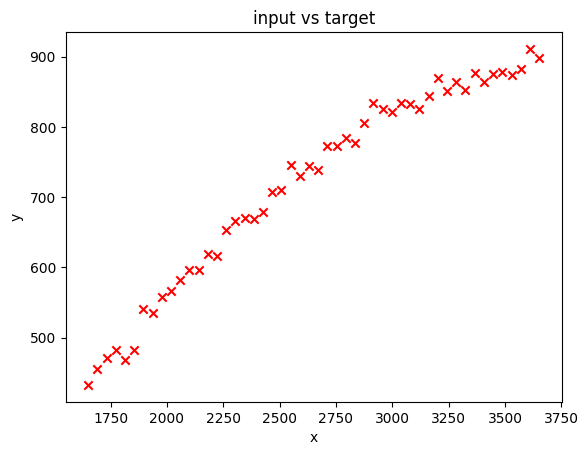

In [6]:
plot_data(x=x,y=y,title='input vs target')

In [7]:
#split train,cv,test
x_train,_x,y_train,_y=train_test_split(x,y,test_size=0.40,random_state=1)

x_cv,x_test,y_cv,y_test=train_test_split(_x,_y,test_size=0.50,random_state=1)

del _x,_y

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_cv.shape}\n")
print(f"the shape of the test set (input) is: {x_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (30, 1)
the shape of the training set (target) is: (30, 1)

the shape of the cross validation set (input) is: (10, 1)
the shape of the cross validation set (target) is: (10, 1)

the shape of the test set (input) is: (10, 1)
the shape of the test set (target) is: (10, 1)


In [8]:
def plot_train_cv_test(x_train,y_train,x_cv,y_cv,x_test,y_test,title):
    plt.scatter(x_train,y_train,marker='x',c='r',label='training')
    plt.scatter(x_cv,y_cv,marker='o',c='b',label='cross_validation')
    plt.scatter(x_test,y_test,marker='^',c='g',label='test')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

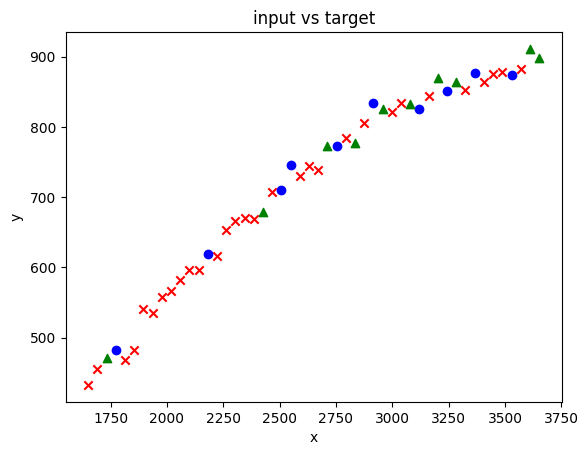

In [9]:
plot_train_cv_test(x_train,y_train,x_cv,y_cv,x_test,y_test,title='input vs target')

Computed mean of the training set: 2504.06
Computed standard deviation of the training set: 574.85


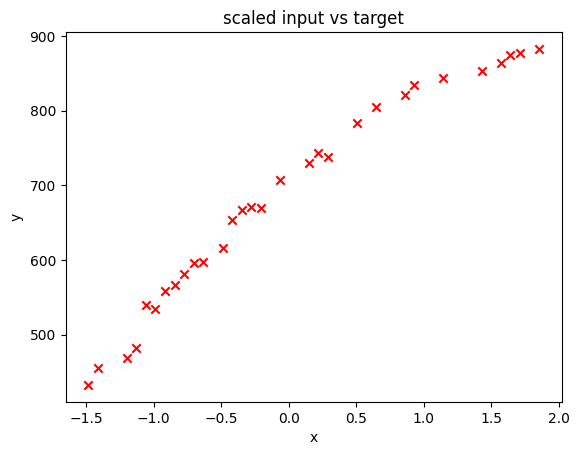

In [10]:
#scaling

scaler_linear=StandardScaler()
X_train_scaled=scaler_linear.fit_transform(x_train)
print(f"Computed mean of the training set: {scaler_linear.mean_.squeeze():.2f}")
print(f"Computed standard deviation of the training set: {scaler_linear.scale_.squeeze():.2f}")

plot_data(X_train_scaled,y_train,title='scaled input vs target')


In [11]:
#Linear Model
linear_model=LinearRegression()
linear_model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[136.36]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[681.55]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5.48]


In [12]:
yhat=linear_model.predict(X_train_scaled)

# Use scikit-learn's utility function and divide by 2
print(f"training MSE (using sklearn function): {mean_squared_error(y_train, yhat) / 2}")

total_squared_error=0
for i in range(len(yhat)):
    total_squared_error+=(yhat[i]-y_train[i])**2
mse = total_squared_error / (2*len(yhat))

print(f"training MSE (for-loop implementation): {mse.squeeze()}")

training MSE (using sklearn function): 406.19374192533155
training MSE (for-loop implementation): 406.19374192533155


In [13]:
X_cv_scaled=scaler_linear.transform(x_cv)
print(f"Mean used to scale the CV set: {scaler_linear.mean_.squeeze():.2f}")
print(f"Standard deviation used to scale the CV set: {scaler_linear.scale_.squeeze():.2f}")

# Feed the scaled cross validation set
yhat = linear_model.predict(X_cv_scaled)

# Use scikit-learn's utility function and divide by 2
print(f"Cross validation MSE: {mean_squared_error(y_cv, yhat) / 2}")

Mean used to scale the CV set: 2504.06
Standard deviation used to scale the CV set: 574.85
Cross validation MSE: 551.7789026952216


In [14]:
#adding polynomial features

poly=PolynomialFeatures(degree=2,include_bias=False)
X_train_mapped=poly.fit_transform(x_train)


print(X_train_mapped[:5])

[[3.32446939e+03 1.10520967e+07]
 [2.34487755e+03 5.49845073e+06]
 [3.48773469e+03 1.21642933e+07]
 [2.63059184e+03 6.92001341e+06]
 [2.58977551e+03 6.70693719e+06]]


In [15]:
scaler_poly=StandardScaler()
X_train_mapped_scaled=scaler_poly.fit_transform(X_train_mapped)

print(X_train_mapped_scaled[:5])

[[ 1.42715997  1.47236856]
 [-0.27691164 -0.36461881]
 [ 1.71117191  1.84025141]
 [ 0.22010925  0.1055935 ]
 [ 0.14910627  0.03511397]]


In [16]:
model=LinearRegression()
model.fit(X_train_mapped_scaled,y_train)

yhat=model.predict(X_train_mapped_scaled)
print(f"Training MSE: {mean_squared_error(y_train, yhat) / 2}")

X_cv_mapped=poly.transform(x_cv)
X_cv_mapped_scaled=scaler_poly.transform(X_cv_mapped)

yhat = model.predict(X_cv_mapped_scaled)
print(f"Cross validation MSE: {mean_squared_error(y_cv, yhat) / 2}")

Training MSE: 49.111609334025154
Cross validation MSE: 87.6984121111191


In [17]:
train_mses=[]
cv_mses=[]
models=[]
polys=[]
scalers=[]

for degree in range(1,11):
    #add poly features
    poly=PolynomialFeatures(degree,include_bias=False)
    X_train_mapped=poly.fit_transform(x_train)
    polys.append(poly)

    #scaled traing set
    scaler_poly=StandardScaler()
    X_train_mapped_scaled=scaler_poly.fit_transform(X_train_mapped)
    scalers.append(scaler_poly)

    #create and train model
    model=LinearRegression()
    model.fit(X_train_mapped_scaled,y_train)
    models.append(model)

    #compute train mse
    yhat=model.predict(X_train_mapped_scaled)
    train_mse=mean_squared_error(y_train,yhat)/2
    train_mses.append(train_mse)

    #add poly features to cv set and scaled them
    
    X_cv_mapped=poly.transform(x_cv)
    X_cv_mapped_scaled=scaler_poly.transform(X_cv_mapped)

    #compute cv error
    yhat=model.predict(X_cv_mapped_scaled)
    cv_mse=mean_squared_error(y_cv,yhat)/2
    cv_mses.append(cv_mse)
    
    
    

    

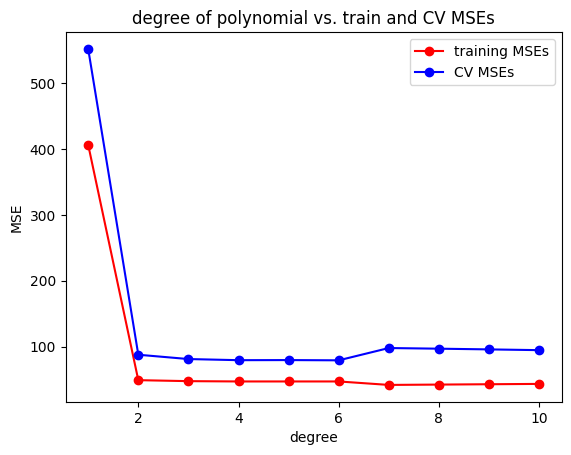

[551.7789026952216,
 87.6984121111191,
 81.15087907196991,
 79.43134912070437,
 79.58685943660328,
 79.21542326187718,
 97.8641403511411,
 96.87822052210029,
 95.80235705735242,
 94.6525064339842]

In [20]:
degrees=range(1,11)
def plot_train_cv_mses(degrees, train_mses, cv_mses, title):
    plt.plot(degrees, train_mses, marker='o', c='r', label='training MSEs'); 
    plt.plot(degrees, cv_mses, marker='o', c='b', label='CV MSEs'); 
    plt.title(title)
    plt.xlabel("degree"); 
    plt.ylabel("MSE"); 
    plt.legend()
    plt.show()

plot_train_cv_mses(degrees, train_mses, cv_mses, title="degree of polynomial vs. train and CV MSEs")
cv_mses

In [19]:
#get model with least cv mse
degree = np.argmin(cv_mses) + 1
print(f"Lowest CV MSE is found in the model with degree={degree}")

Lowest CV MSE is found in the model with degree=6


In [23]:
#add poly features
X_test_mapped=polys[degree-1].transform(x_test)

#scale
X_test_mapped_scaled=scalers[degree-1].transform(X_test_mapped)

#compute mse
yhat=models[degree-1].predict(X_test_mapped_scaled)
test_mse=mean_squared_error(y_test,yhat)/2

print(f"Training MSE: {train_mses[degree-1]:.2f}")
print(f"Cross Validation MSE: {cv_mses[degree-1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

Training MSE: 47.15
Cross Validation MSE: 79.22
Test MSE: 101.50
